# Two-clusters example — heat-kernel RiePCA

Two filled ellipses at $(1,1)$ and $(6,6)$, analysed with RiePCA at a
sequence of absolute heat times. The numerical engine is
[`riepca_euclidean.py`](riepca_euclidean.py); this notebook supplies only the
data, the reference-point selection, and the figures.

The **absolute heat time $t$** is used everywhere — no relative-time
conversion and no hidden rescaling. Values supplied in `T_VALUES` are passed
directly to

$$
k_t(x,y)=(4\pi t)^{-d/2}
\exp\!\left(-\frac{\lVert x-y\rVert^2}{4t}\right).
$$

The steps are:

1. sample the two clusters and fix the weights $\mu$;
2. select local diffusion-Fréchet minima separately at each requested $t$;
3. fit RiePCA at every $t$ through `riepca_euclidean.fit_riepca`;
4. validate the numerical identities and visualize the components.

## Input contract

- `data_points`: an array of shape `(n, d)`;
- `mu`: an optional probability vector of length `n`;
- `t_values`: positive absolute heat times, in squared data-coordinate units;
- `reference_points`: either one fixed array of shape `(r, d)` used at every
  $t$, or a dictionary `{t: array}` when references are selected separately at
  each heat time. This notebook uses the dictionary form.


## 0. The RiePCA engine

**The mathematics, stated once.** With
$\kappa_t(x,y)=(4\pi t)^{-d/2}e^{-\lVert x-y\rVert^2/4t}$, each observation $y$
becomes a vector *field* sampled at the references $x_1,\dots,x_r$:

$$g_{t,y}(x_a)=\nabla_{\!x}\kappa_t(x_a,y)=\kappa_t(x_a,y)\,\frac{y-x_a}{2t},$$

living in $H_R=(\mathbb R^d)^r$ with
$\langle U,V\rangle_R=\sum_a\omega_a\,U(x_a)^{\top}V(x_a)$. RiePCA is the
$\mu$-weighted PCA of these fields after centring on the **field mean** —
never a Fréchet mean.

The hard ceiling on the number of components is the **field capacity**
$\dim H_R=r\cdot d$, further capped by the rank $\,\#\{\mu_i>0\}-1$ that
centring leaves. Asking for more returns fewer.


In [19]:
# --- locate and import the RiePCA engine ---------------------------------
# Put riepca_euclidean.py next to this notebook. In Colab: the file pane on
# the left (it survives until the runtime is recycled), or keep it in Drive
# and mount it, which survives restarts.
import sys
from pathlib import Path

_candidates = [Path.cwd(), Path("/content"), Path("/content/drive/MyDrive"),
               Path.cwd() / "upload", Path("/content/drive/MyDrive/riepca")]
_home = next((p for p in _candidates if (p / "riepca_euclidean.py").exists()), None)
if _home is None:
    raise FileNotFoundError(
        "riepca_euclidean.py not found. Upload it next to this notebook and "
        "rerun this cell. Searched: " + ", ".join(str(p) for p in _candidates))
if str(_home) not in sys.path:
    sys.path.insert(0, str(_home))

import numpy as np
import riepca_euclidean
from riepca_euclidean import (
    validate_weighted_point_cloud, validate_reference_points,
    heat_kernel_values, heat_gradient_fields, field_capacity, check_riepca,
    degenerate_blocks, block_magnitude, block_angle, block_summary,
    check_block_invariance,
    plot_eigenvalues, plot_variance_explained, plot_cumulative_variance,
    plot_spectrum_across_t, plot_block_magnitude,
)


def validate_t_values(t_values=None):
    """Validate and return a nonempty 1-D array of positive heat times.

    Same contract riepca_euclidean.fit_riepca applies internally; kept here so
    the data cell can check T_VALUES before any fitting happens.
    """
    if t_values is None:
        t_values = (0.5, 1.0, 3.0, 6.0, 12.0)
    times = np.asarray(list(t_values), dtype=float)
    if times.ndim != 1 or times.size == 0:
        raise ValueError("t_values must be a nonempty one-dimensional sequence.")
    if np.any(~np.isfinite(times)) or np.any(times <= 0):
        raise ValueError("Every heat time t must be positive and finite.")
    if np.unique(times).size != times.size:
        raise ValueError("t_values must not contain duplicates.")
    return times


def result_field_capacity(result):
    """r*d for a fitted result, under either riepca_euclidean revision.

    The attribute was renamed feature_capacity -> field_capacity; accept both
    so the notebook does not depend on which revision is installed.
    """
    for _name in ("field_capacity", "feature_capacity", "capacity"):
        if hasattr(result, _name):
            return int(getattr(result, _name))
    raise AttributeError("result carries no field-capacity attribute")


print("riepca_euclidean loaded from", _home / "riepca_euclidean.py")


riepca_euclidean loaded from /content/riepca_euclidean.py


In [21]:
from __future__ import annotations

import numpy as np
import scipy.linalg as la


In [22]:
# Plotting setup: make every figure both DISPLAY and SAVE.

%matplotlib inline
import os
from pathlib import Path
import matplotlib.pyplot as plt

# Single place that controls where figures go and whether they show.
FIGURE_DIR = Path("heat_kernel_RiePCA_plots")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
SHOW_FIGURES = True          # set False for headless/batch runs
SAVE_DPI = 200


def time_tag(t):
    """Return a filename-safe label for an absolute heat time."""
    return f"{float(t):g}".replace(".", "p").replace("-", "m")


def finalize(fig, name, *, subdir=None, formats=("png", "pdf")):
    """Save `fig` under FIGURE_DIR/[subdir] as `name`, then show or close it."""
    target = FIGURE_DIR if subdir is None else FIGURE_DIR / subdir
    target.mkdir(parents=True, exist_ok=True)
    written = []
    for ext in formats:
        path = target / f"{name}.{ext}"
        fig.savefig(path, dpi=SAVE_DPI, bbox_inches="tight", facecolor="white")
        written.append(path)
    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)
    return written


## 1. Two-clusters experiment

The parameters below match the companion paper notebook. In particular, the
analysis uses the explicit heat times

```python
T_VALUES = (0.5, 1.0, 3.0, 6.0, 12.0)
```

and selects local diffusion-Fréchet minima separately at each $t$. These
time-specific reference arrays are passed to
`riepca_euclidean.fit_riepca` as a dictionary keyed by $t$.


### Synthetic dataset

data shape: (1400, 2)
mu sum: 1.0
cluster masses: 0.5 0.5
weighted mean: [3.5123 3.4928]
weighted data variance (context only): 14.3877


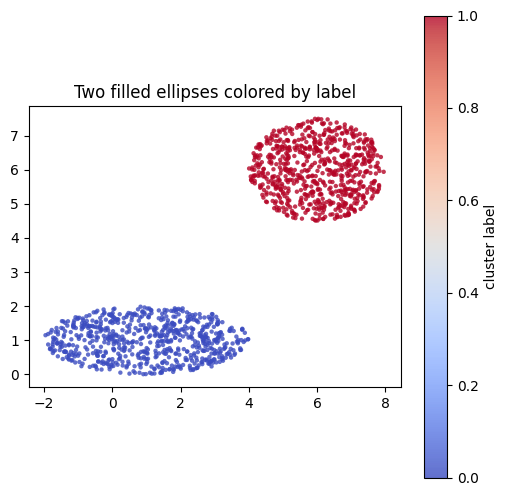

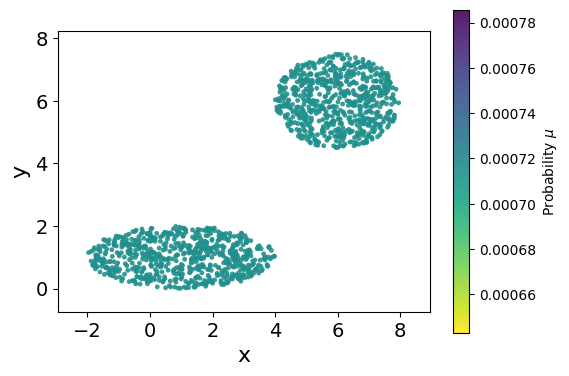


       t   seeds references  reference coordinates
------------------------------------------------------------------------------
     0.5       2          2  [[6.0022, 5.9745], [1.1467, 1.0195]]
       1       2          2  [[5.965, 5.9361], [1.1247, 1.0465]]
       3       2          1  [[4.3185, 4.1538]]
       6       3          1  [[3.6371, 3.5336]]
      12       2          1  [[3.5645, 3.5026]]


In [23]:
# Control panel: parameters from RiePCA_two_clusters_(paper)

N_POINTS_1 = 700
N_POINTS_2 = 700
NOISE = 0.0

CENTER_1 = (1.0, 1.0)
CENTER_2 = (6.0, 6.0)

SEMI_AXES_1 = (3.0, 1.0)
SEMI_AXES_2 = (2.0, 1.5)

ANGLE_1 = np.deg2rad(0.0)
ANGLE_2 = np.deg2rad(0.0)

WEIGHT_1 = 0.5
WEIGHT_2 = 0.5
RANDOM_SEED = 42

# Absolute heat times in squared data-coordinate units.
T_VALUES = (0.5, 1.0, 3.0, 6.0, 12.0)
TOP_K = 16

# Local diffusion-Fréchet reference selection.
LOCAL_MIN_NEIGHBORS = 20
N_REFERENCES = 12
MEAN_SHIFT_TOL = 1e-10
MEAN_SHIFT_MAX_ITER = 1000
MODE_MERGE_TOL = 1e-6



# Output directory

out_dir = (
    f"TwoEllipses+FrechetMean[RiePCA]_"
    f"n{N_POINTS_1 + N_POINTS_2}_"
    f"c1_{CENTER_1[0]}_{CENTER_1[1]}_"
    f"c2_{CENTER_2[0]}_{CENTER_2[1]}_"
    f"noise_{NOISE}"
)
os.makedirs(out_dir, exist_ok=True)



# Dataset generation

def sample_filled_ellipse(n, center, a, b, angle, rng):
    """Sample points uniformly with respect to area inside an ellipse."""
    radius = np.sqrt(rng.uniform(0.0, 1.0, size=n))
    phase = rng.uniform(0.0, 2.0 * np.pi, size=n)

    x = a * radius * np.cos(phase)
    y = b * radius * np.sin(phase)

    cosine = np.cos(angle)
    sine = np.sin(angle)
    x_rotated = x * cosine - y * sine
    y_rotated = x * sine + y * cosine

    return np.column_stack([
        center[0] + x_rotated,
        center[1] + y_rotated,
    ])


rng = np.random.default_rng(RANDOM_SEED)

cloud_1 = sample_filled_ellipse(
    N_POINTS_1, CENTER_1, *SEMI_AXES_1, ANGLE_1, rng
)
cloud_2 = sample_filled_ellipse(
    N_POINTS_2, CENTER_2, *SEMI_AXES_2, ANGLE_2, rng
)

if NOISE > 0:
    cloud_1 += rng.normal(0.0, NOISE, size=cloud_1.shape)
    cloud_2 += rng.normal(0.0, NOISE, size=cloud_2.shape)

data_points = np.vstack([cloud_1, cloud_2])

mu = np.concatenate([
    np.full(N_POINTS_1, WEIGHT_1 / N_POINTS_1),
    np.full(N_POINTS_2, WEIGHT_2 / N_POINTS_2),
])
mu = mu / mu.sum()

labels = np.concatenate([
    np.zeros(N_POINTS_1, dtype=int),
    np.ones(N_POINTS_2, dtype=int),
])

weighted_mean = mu @ data_points
weighted_variance = float(
    mu @ np.sum((data_points - weighted_mean) ** 2, axis=1)
)

print("data shape:", data_points.shape)
print("mu sum:", mu.sum())
print("cluster masses:", mu[labels == 0].sum(), mu[labels == 1].sum())
print("weighted mean:", np.round(weighted_mean, 4))
print("weighted data variance (context only):", round(weighted_variance, 4))



# Dataset plots

fig, ax = plt.subplots(figsize=(6, 6))
scatter = ax.scatter(
    data_points[:, 0],
    data_points[:, 1],
    c=labels,
    cmap="coolwarm",
    s=10,
    alpha=0.8,
    edgecolors="none",
)
fig.colorbar(scatter, ax=ax, label="cluster label")
ax.set_aspect("equal", adjustable="box")
ax.set_title("Two filled ellipses colored by label")
finalize(fig, "dataset_labels", subdir="Data")

FONT_SIZE = 16
fig, ax = plt.subplots(figsize=(6, 6))
scatter = ax.scatter(
    data_points[:, 0],
    data_points[:, 1],
    c=mu,
    cmap="viridis_r",
    s=12,
    alpha=0.9,
    edgecolors="none",
)
fig.colorbar(scatter, ax=ax, label=r"Probability $\mu$", shrink=0.7)
ax.set_xlabel("x", fontsize=FONT_SIZE)
ax.set_ylabel("y", fontsize=FONT_SIZE)
ax.tick_params(axis="both", labelsize=FONT_SIZE - 2)
ax.set_aspect("equal", adjustable="box")
ax.margins(0.1)
finalize(fig, "dataset_mu", subdir="Data")



# Per-t local diffusion-Fréchet minima

from scipy.spatial import cKDTree


def local_diffusion_frechet_minima(
    points,
    probability,
    t,
    *,
    n_neighbors=20,
    n_references=12,
    mean_shift_tol=1e-10,
    mean_shift_max_iter=1000,
    mode_merge_tol=1e-6,
):
    """
    Find continuous local minima of the diffusion-Fréchet function.

    Sample-based k-nearest-neighbor minima supply deterministic starting points.
    Gaussian mean-shift then refines each start to a continuous local minimum,
    and coincident limiting modes are merged. If more than `n_references`
    minima survive, retain those with the smallest Fréchet values.
    """
    points, probability = validate_weighted_point_cloud(points, probability)
    t = float(t)
    n, d = points.shape

    # By the heat-kernel semigroup,
    # d_t(x_i, y_j)^2 = k_{2t}(x_i,x_i) + k_{2t}(y_j,y_j)
    #                    - 2 k_{2t}(x_i,y_j).
    kernel_2t = heat_kernel_values(points, points, 2.0 * t)
    diagonal_value = (8.0 * np.pi * t) ** (-d / 2.0)
    frechet_values = 2.0 * diagonal_value - 2.0 * (kernel_2t @ probability)

    k_query = min(int(n_neighbors) + 1, n)
    tree = cKDTree(points)
    _, neighbor_indices = tree.query(points, k=k_query)
    neighbor_indices = np.atleast_2d(neighbor_indices)
    neighbor_indices = neighbor_indices[:, 1:]

    tolerance = 1e-12 * max(
        1.0,
        float(np.max(np.abs(frechet_values))),
    )
    is_local_minimum = np.all(
        frechet_values[:, None]
        <= frechet_values[neighbor_indices] + tolerance,
        axis=1,
    )
    seed_indices = np.flatnonzero(is_local_minimum)

    if seed_indices.size == 0:
        seed_indices = np.array([int(np.argmin(frechet_values))])

    # Refine each discrete seed to a continuous KDE mode. Minimizing F_t is
    # equivalent to maximizing sum_i mu_i k_(2t)(x, y_i), whose fixed-point
    # update is Gaussian mean-shift with exp(-||x-y_i||^2 / (8t)) weights.
    extent = float(np.max(np.ptp(points, axis=0)))
    convergence_scale = max(1.0, extent, np.sqrt(t))
    merge_threshold = float(mode_merge_tol) * convergence_scale
    modes = []

    for seed_index in seed_indices:
        current = points[int(seed_index)].copy()

        for _ in range(int(mean_shift_max_iter)):
            squared_distances = np.sum((points - current) ** 2, axis=1)
            mode_weights = probability * np.exp(
                -squared_distances / (8.0 * t)
            )
            updated = (mode_weights @ points) / mode_weights.sum()

            if np.linalg.norm(updated - current) <= (
                float(mean_shift_tol)
                * max(1.0, np.linalg.norm(current))
            ):
                current = updated
                break

            current = updated
        else:
            raise RuntimeError(
                f"Mean-shift did not converge at t={t:g}; "
                "increase MEAN_SHIFT_MAX_ITER."
            )

        if not any(
            np.linalg.norm(current - existing) <= merge_threshold
            for existing in modes
        ):
            modes.append(current)

    modes = np.asarray(modes, dtype=float)

    # Deterministic ordering by continuous Fréchet value, then coordinates.
    mode_kernel = heat_kernel_values(points, modes, 2.0 * t).T
    mode_frechet_values = (
        2.0 * diagonal_value
        - 2.0 * (mode_kernel @ probability)
    )
    coordinate_keys = tuple(
        modes[:, coordinate]
        for coordinate in reversed(range(modes.shape[1]))
    )
    order = np.lexsort(coordinate_keys + (mode_frechet_values,))
    modes = modes[order][: int(n_references)]

    return modes, frechet_values, seed_indices


t_values_requested = validate_t_values(T_VALUES)
reference_points = {}
reference_seed_indices_dict = {}
frechet_values_dict = {}

for t_raw in t_values_requested:
    t = float(t_raw)
    references, frechet_values, seed_indices = local_diffusion_frechet_minima(
        data_points,
        mu,
        t,
        n_neighbors=LOCAL_MIN_NEIGHBORS,
        n_references=N_REFERENCES,
        mean_shift_tol=MEAN_SHIFT_TOL,
        mean_shift_max_iter=MEAN_SHIFT_MAX_ITER,
        mode_merge_tol=MODE_MERGE_TOL,
    )
    reference_seed_indices_dict[t] = seed_indices
    reference_points[t] = references
    frechet_values_dict[t] = frechet_values

print()
print(f"{'t':>8} {'seeds':>7} {'references':>10}  reference coordinates")
print("-" * 78)
for t in t_values_requested:
    t = float(t)
    print(
        f"{t:8g} {len(reference_seed_indices_dict[t]):7d} "
        f"{len(reference_points[t]):10d}  "
        f"{np.round(reference_points[t], 4).tolist()}"
    )


### Fit RiePCA at every heat time through riepca_euclidean

In [24]:
_fits = riepca_euclidean.fit_riepca(
    data_points,
    reference_points,          # {t: (r, d) array}, one per heat time
    t_values=T_VALUES,
    mu=mu,
    k_keep=TOP_K,
)

t_values = [float(t) for t in T_VALUES]
_n_obs = data_points.shape[0]
_evals_all = np.full((len(t_values), TOP_K), np.nan)
_proj_all = np.full((_n_obs, TOP_K, len(t_values)), np.nan)
_diagnostics = {}
for _j, _t in enumerate(t_values):
    _res = _fits[_t]
    _k = _res.n_components
    _evals_all[_j, :_k] = _res.eigenvalues
    _proj_all[:, :_k, _j] = _res.scores
    _rep = check_riepca(_res)          # raises if any identity fails
    _diagnostics[_t] = {
        "n_retained_pcs": _k,
        "component_orthonormality_error": _rep["orthonormality_error"],
        "weighted_projection_mean_error": _rep["score_mean_error"],
        "relative_score_covariance_error": _rep["score_covariance_error_relative"],
    }

riepca_results = {
    "t_values": t_values,
    "by_t": {t: {"eigenvalues": _fits[t].eigenvalues, "result": _fits[t]}
             for t in t_values},
    "data_points": data_points,
    "weighted_data_mean": mu @ data_points,
    "evals_all": _evals_all,
    "evecs_dict": {t: _fits[t].components for t in t_values},
    "projections": _proj_all,
    "projections_dict": {t: _fits[t].scores for t in t_values},
    "mean_field_dict": {t: _fits[t].mean_field for t in t_values},
    "reference_points_dict": {t: _fits[t].reference_points for t in t_values},
    "pc_fields_dict": {t: _fits[t].pc_fields for t in t_values},
    "diagnostics": _diagnostics,
}

# Familiar names for the downstream plotting cells.
evals_all = riepca_results["evals_all"]
evecs_all = riepca_results["evecs_dict"]
projections = riepca_results["projections"]
projections_dict = riepca_results["projections_dict"]
mean_field_dict = riepca_results["mean_field_dict"]
ref_points_all = riepca_results["reference_points_dict"]
pc_fields_dict = riepca_results["pc_fields_dict"]

print("data shape:", data_points.shape)
print("weighted spatial mean:", riepca_results["weighted_data_mean"])
print("stored heat times:", t_values)
print()

header = (f"{'t':>8} {'refs':>5} {'PCs':>4} "
          f"{'orth err':>10} {'mean err':>10} {'cov err':>10}")
print(header)
print("-" * len(header))
for t in t_values:
    report = riepca_results["diagnostics"][t]
    print(f"{t:8g} "
          f"{ref_points_all[t].shape[0]:5d} "
          f"{report['n_retained_pcs']:4d} "
          f"{report['component_orthonormality_error']:10.1e} "
          f"{report['weighted_projection_mean_error']:10.1e} "
          f"{report['relative_score_covariance_error']:10.1e}")


data shape: (1400, 2)
weighted spatial mean: [3.51226352 3.4927941 ]
stored heat times: [0.5, 1.0, 3.0, 6.0, 12.0]

       t  refs  PCs   orth err   mean err    cov err
----------------------------------------------------
     0.5     2    4    2.2e-16    2.1e-17    6.7e-16
       1     2    4    6.7e-16    3.3e-17    5.1e-16
       3     1    2    0.0e+00    1.0e-15    4.4e-16
       6     1    2    1.1e-16    1.0e-15    4.4e-16
      12     1    2    2.2e-16    5.3e-16    6.7e-16


### Numerical consistency checks.

In [25]:
# First verify the analytic formula against a central finite difference in x.
t_check = t_values[min(2, len(t_values) - 1)]
y_check = data_points[[0]]
x_check = ref_points_all[t_check][[0]].copy()
analytic_gradient = heat_gradient_fields(y_check, x_check, t_check)[0, 0]
step = 1e-6 * max(1.0, np.sqrt(t_check))
finite_difference_gradient = np.empty_like(analytic_gradient)

for coordinate in range(x_check.shape[1]):
    x_plus = x_check.copy()
    x_minus = x_check.copy()
    x_plus[0, coordinate] += step
    x_minus[0, coordinate] -= step
    k_plus = heat_kernel_values(y_check, x_plus, t_check)[0, 0]
    k_minus = heat_kernel_values(y_check, x_minus, t_check)[0, 0]
    finite_difference_gradient[coordinate] = (
        k_plus - k_minus
    ) / (2.0 * step)

gradient_relative_error = float(
    la.norm(analytic_gradient - finite_difference_gradient)
    / max(la.norm(finite_difference_gradient), np.finfo(float).tiny)
)
print(
    "heat-gradient finite-difference relative error: "
    f"{gradient_relative_error:.2e}"
)
assert gradient_relative_error < 1e-6
print()

for t in t_values:
    report = riepca_results["diagnostics"][t]
    print(
        f"t={t:8g} | "
        f"PCs={report['n_retained_pcs']:2d} | "
        f"orth err={report['component_orthonormality_error']:.2e} | "
        f"weighted mean err={report['weighted_projection_mean_error']:.2e} | "
        f"score covariance err={report['relative_score_covariance_error']:.2e}"
    )


heat-gradient finite-difference relative error: 2.58e-10

t=     0.5 | PCs= 4 | orth err=2.22e-16 | weighted mean err=2.12e-17 | score covariance err=6.66e-16
t=       1 | PCs= 4 | orth err=6.66e-16 | weighted mean err=3.32e-17 | score covariance err=5.06e-16
t=       3 | PCs= 2 | orth err=0.00e+00 | weighted mean err=1.03e-15 | score covariance err=4.44e-16
t=       6 | PCs= 2 | orth err=1.11e-16 | weighted mean err=1.05e-15 | score covariance err=4.44e-16
t=      12 | PCs= 2 | orth err=2.22e-16 | weighted mean err=5.28e-16 | score covariance err=6.66e-16


## 2. Verifying the requested heat-time grid

`fit_riepca` uses `t_values` directly. The stored list and every time-indexed
dictionary therefore use the same absolute heat times supplied in `T_VALUES`.

`numpy.testing.assert_allclose` is silent when the check passes, so the next
cell prints an explicit success message after the assertion.


In [26]:
np.testing.assert_allclose(
    np.asarray(riepca_results["t_values"], dtype=float),
    np.asarray(T_VALUES, dtype=float),
)
print("Verified: stored t_values exactly match the requested T_VALUES.")


Verified: stored t_values exactly match the requested T_VALUES.


## Outputs

For each absolute heat time `t`:

- `by_t[t]`: complete single-time RiePCA result;
- `reference_points_dict[t]`: local diffusion-Fréchet minima used at that time;
- `mean_field_dict[t]`: weighted mean heat-gradient field;
- `evecs_dict[t]`: orthonormal RiePCA directions, shape `(r*d, k)`;
- `pc_fields_dict[t]`: the same directions reshaped as `(r, d, k)`;
- `evals_dict[t]`: RiePCA eigenvalues in descending order;
- `projections_dict[t]`: **centered** coordinates, shape `(n, k)`;
- `explained_variance_ratio_dict[t]`: retained variance fractions;
- `diagnostics[t]`: numerical consistency checks.

The padded array `projections` has shape `(n, top_k, n_times)` for convenient
plotting. Missing PCs are represented by `NaN`, not zero.


### Projecting data to PC1--PC2 plane

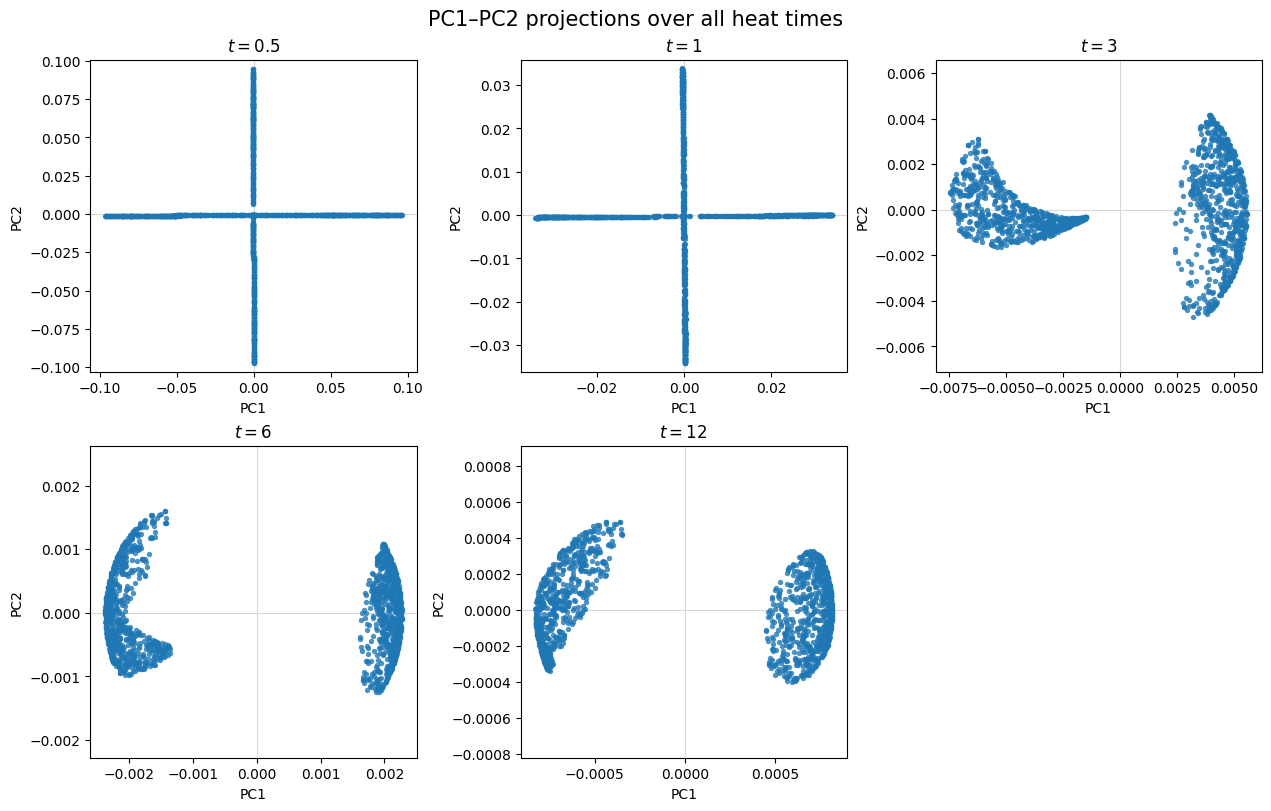

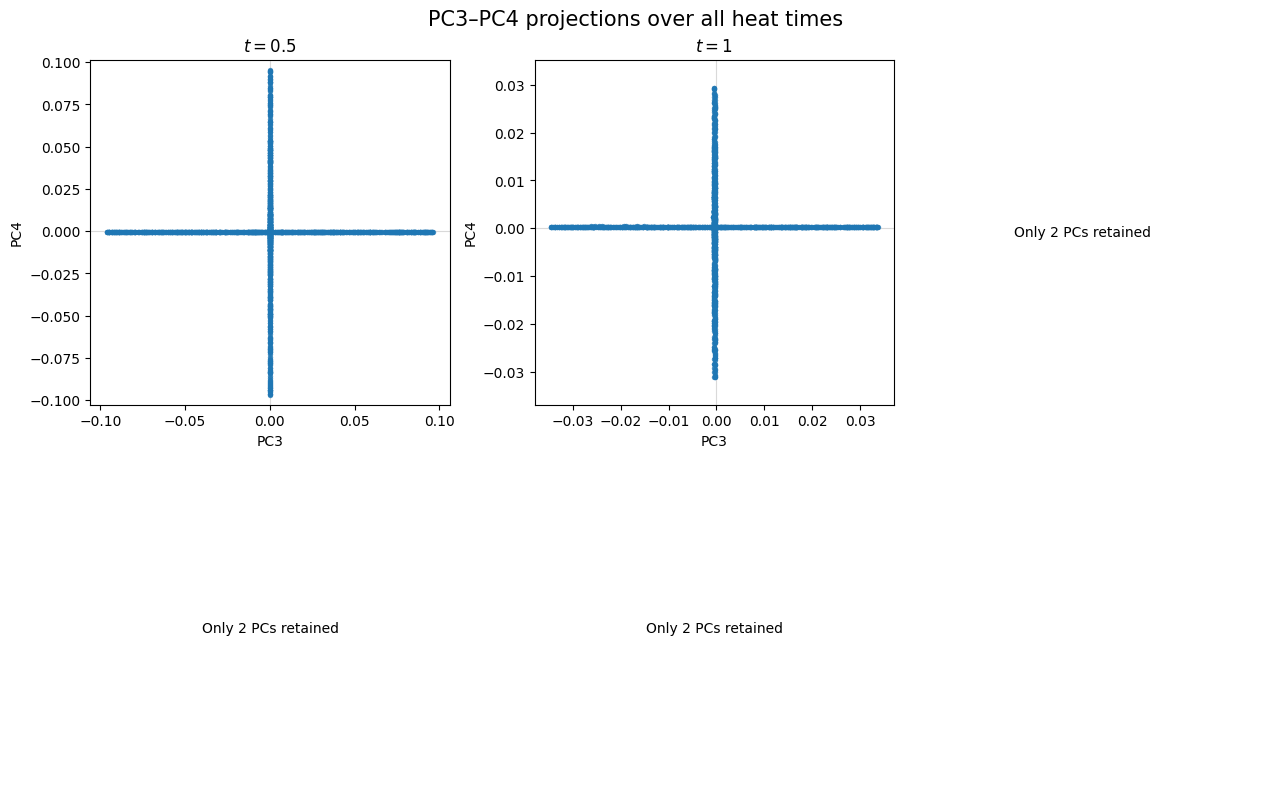

In [27]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Optional coloring; e.g. color_values = labels
color_values = None
color_label = None


def plot_pc_pair_all_t(pc_x, pc_y, ncols=3):
    """Scatter PC(pc_x) against PC(pc_y) across all heat times."""
    ix, iy = pc_x - 1, pc_y - 1

    n_t = len(t_values)
    ncols = min(ncols, n_t)
    nrows = math.ceil(n_t / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.2 * ncols, 4.0 * nrows),
        squeeze=False,
        constrained_layout=True,
    )
    axes = axes.ravel()
    scatter = None

    for ax, t in zip(axes, t_values):
        scores = projections_dict[t]

        if scores.shape[1] <= max(ix, iy):
            ax.text(
                0.5,
                0.5,
                f"Only {scores.shape[1]} PCs retained",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_axis_off()
            continue

        kwargs = dict(
            s=15,
            alpha=0.8,
            linewidths=0,
            rasterized=True,
        )
        if color_values is None:
            kwargs["color"] = "tab:blue"
        else:
            kwargs.update(c=np.asarray(color_values), cmap="viridis")

        scatter = ax.scatter(scores[:, ix], scores[:, iy], **kwargs)
        ax.set_title(rf"$t={t:g}$")
        ax.set_xlabel(f"PC{pc_x}")
        ax.set_ylabel(f"PC{pc_y}")
        ax.set_aspect("equal", adjustable="datalim")
        ax.axhline(0, color="0.85", linewidth=0.8, zorder=0)
        ax.axvline(0, color="0.85", linewidth=0.8, zorder=0)

    for ax in axes[n_t:]:
        ax.set_axis_off()

    fig.suptitle(
        rf"PC{pc_x}–PC{pc_y} projections over all heat times",
        fontsize=15,
    )

    if color_values is not None and scatter is not None:
        fig.colorbar(
            scatter,
            ax=[ax for ax in axes[:n_t] if ax.axison],
            label=color_label,
            shrink=0.85,
        )

    finalize(
        fig,
        f"scores_PC{pc_x}_PC{pc_y}_all_t",
        subdir="scores",
    )
    return fig


fig_pc12 = plot_pc_pair_all_t(1, 2)
fig_pc34 = plot_pc_pair_all_t(3, 4)


### Principal Vector Fields

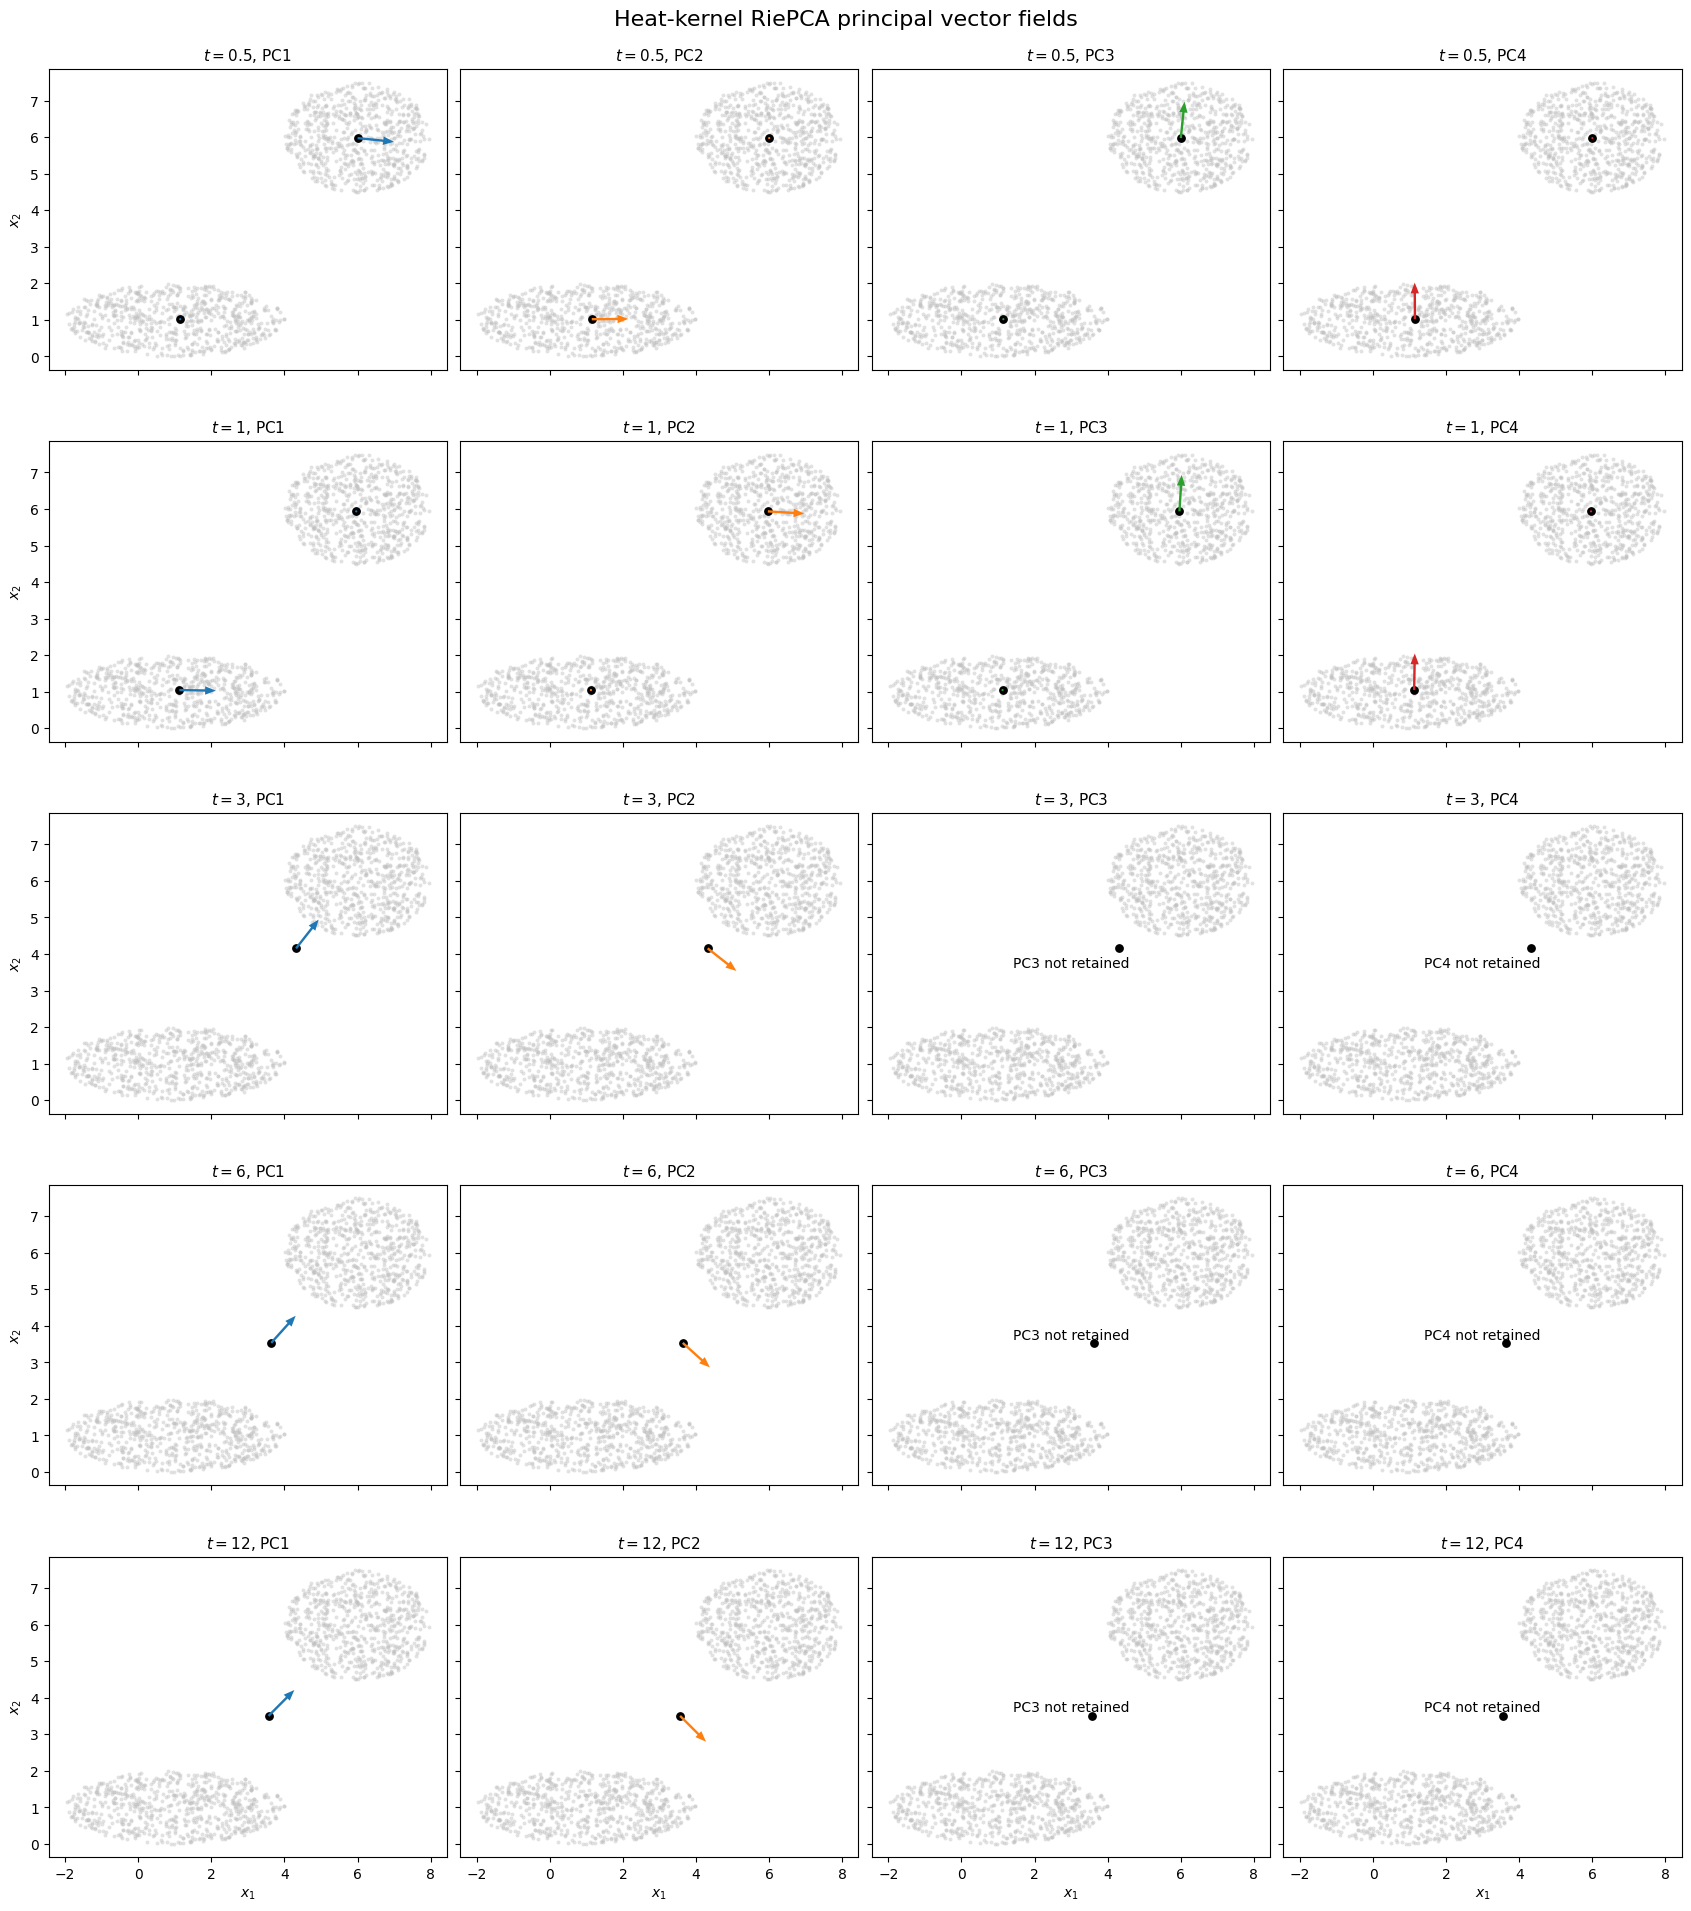

[PosixPath('heat_kernel_RiePCA_plots/fields/principal_vector_fields_PC1_PC4_all_t.png'),
 PosixPath('heat_kernel_RiePCA_plots/fields/principal_vector_fields_PC1_PC4_all_t.pdf')]

In [28]:
import numpy as np
import matplotlib.pyplot as plt

data_points_2d = riepca_results["data_points"]
t_values = riepca_results["t_values"]
ref_points_all = riepca_results["reference_points_dict"]
pc_fields_dict = riepca_results["pc_fields_dict"]

if data_points_2d.shape[1] != 2:
    raise ValueError("This quiver plot requires two-dimensional data.")

n_t = len(t_values)
n_pcs = 4

fig, axes = plt.subplots(
    n_t,
    n_pcs,
    figsize=(4.2 * n_pcs, 3.8 * n_t),
    squeeze=False,
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for row, t in enumerate(t_values):
    refs = ref_points_all[t]
    pc_fields = pc_fields_dict[t]

    for pc_index in range(n_pcs):
        ax = axes[row, pc_index]
        ax.scatter(
            data_points_2d[:, 0],
            data_points_2d[:, 1],
            s=8,
            color="0.75",
            alpha=0.45,
            linewidths=0,
            rasterized=True,
        )
        ax.scatter(
            refs[:, 0],
            refs[:, 1],
            s=28,
            color="black",
            zorder=3,
        )

        if pc_index < pc_fields.shape[2]:
            vectors = pc_fields[:, :, pc_index]
            ax.quiver(
                refs[:, 0],
                refs[:, 1],
                vectors[:, 0],
                vectors[:, 1],
                angles="xy",
                scale_units="xy",
                scale=1.0,
                width=0.006,
                headwidth=3.5,
                headlength=4.5,
                color=f"C{pc_index}",
                zorder=4,
            )
        else:
            ax.text(
                0.5,
                0.5,
                f"PC{pc_index + 1} not retained",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )

        ax.set_title(
            rf"$t={t:g}$, PC{pc_index + 1}",
            fontsize=11,
        )
        ax.set_aspect("equal", adjustable="box")
        if row == n_t - 1:
            ax.set_xlabel(r"$x_1$")
        if pc_index == 0:
            ax.set_ylabel(r"$x_2$")

fig.suptitle(
    "Heat-kernel RiePCA principal vector fields",
    fontsize=16,
)
finalize(
    fig,
    "principal_vector_fields_PC1_PC4_all_t",
    subdir="fields",
)


### PC1–PC4 vector fields overlaid

The next plot overlays the first four available principal vector fields at
selected heat times. For visualization, **each principal field is divided by
its own largest reference-point magnitude**:

$$
\widetilde e_j(x_a)
=
\frac{e_j(x_a)}
{\max_b\lVert e_j(x_b)\rVert}.
$$

This display normalization changes only the plotted arrow lengths. It does not
modify `pc_fields_dict`, the fitted components, eigenvalues, or projections.
If fewer than four components exist at a given $t$, only the available
components are drawn.


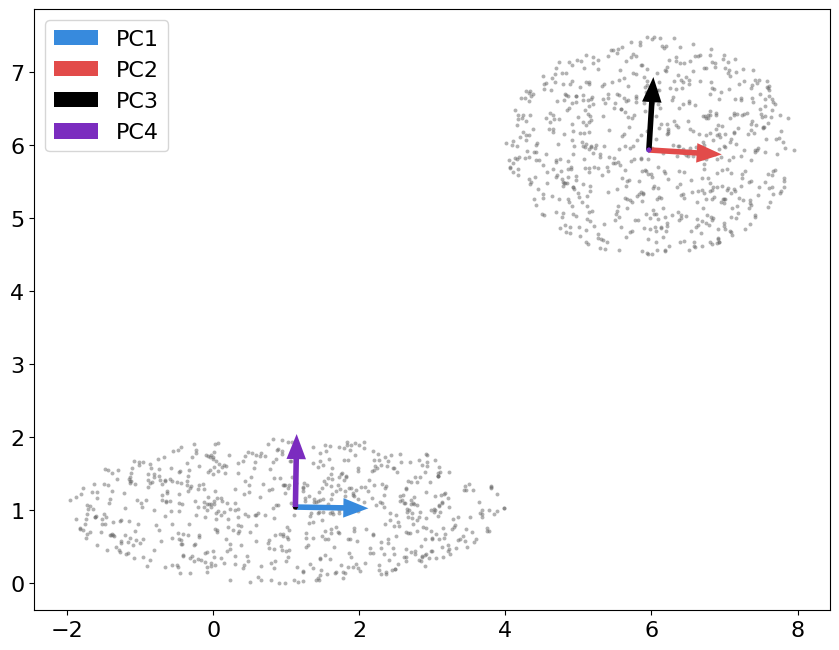

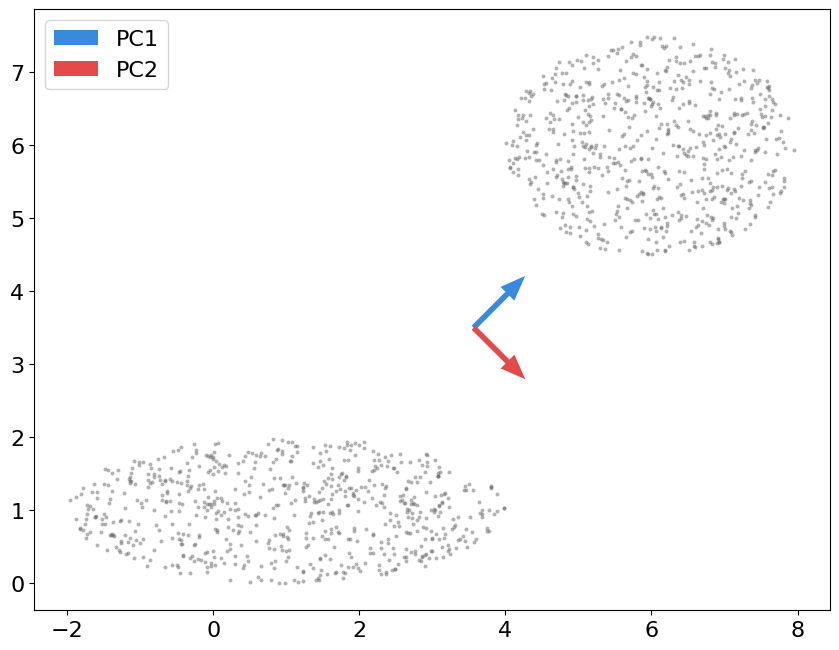

In [34]:
PC_STYLES = [
    {"color": "#378ADD", "label": "PC1"},
    {"color": "#E24B4A", "label": "PC2"},
    {"color": "#000000", "label": "PC3"},
    {"color": "#7B2CBF", "label": "PC4"},
]

SELECTED_T_INDICES = list(dict.fromkeys([
    min(1, len(t_values) - 1),
    len(t_values) - 1,
]))
SELECTED_T_VALUES = [t_values[index] for index in SELECTED_T_INDICES]

for t in SELECTED_T_VALUES:
    references = riepca_results["reference_points_dict"][t]
    pc_fields = riepca_results["pc_fields_dict"][t]
    n_available = min(4, pc_fields.shape[2])

    fig, ax = plt.subplots(figsize=(8.5, 6.8))

    ax.scatter(
        data_points[:, 0],
        data_points[:, 1],
        s=8,
        color="0.4",
        alpha=0.5,
        linewidths=0,
        rasterized=True,
        zorder=1,
    )

    for pc_index in range(n_available):
        vectors = pc_fields[:, :, pc_index]
        magnitudes = np.linalg.norm(vectors, axis=1)
        maximum = float(np.max(magnitudes)) if magnitudes.size else 0.0
        vectors_to_plot = vectors / maximum if maximum > 0 else vectors.copy()
        style = PC_STYLES[pc_index]

        ax.quiver(
            references[:, 0],
            references[:, 1],
            vectors_to_plot[:, 0],
            vectors_to_plot[:, 1],
            angles="xy",
            scale_units="xy",
            scale=1,
            width=0.007,
            headwidth=3.5,
            headlength=4.5,
            color=style["color"],
            alpha=1,
            label=style["label"],
            zorder=4,
        )
    """
    ax.scatter(
        references[:, 0],
        references[:, 1],
        s=40,
        color="black",
        marker="*",
        label="Local min of the diffusion Fréchet function",
        zorder=3,
    )
    """

    #ax.set_title(rf"Principal vector fields at $t={t:g}$", fontsize=17,)
    #ax.set_xlabel(r"$x_1$", fontsize=15)
    #ax.set_ylabel(r"$x_2$", fontsize=15)
    ax.set_aspect("equal", adjustable="box")
    ax.legend(fontsize=16, loc="best", frameon=True)
    ax.tick_params(axis="both", labelsize=16)
    fig.tight_layout()

    finalize(
        fig,
        f"principal_fields_PC1_PC{n_available}_overlay_t_{time_tag(t)}",
        subdir="fields",
    )


In [30]:
# (PDF handling now lives inside finalize(); nothing to close here.)
print("Score-scatter and vector-field figures saved under", FIGURE_DIR.resolve())


Score-scatter and vector-field figures saved under /content/heat_kernel_RiePCA_plots


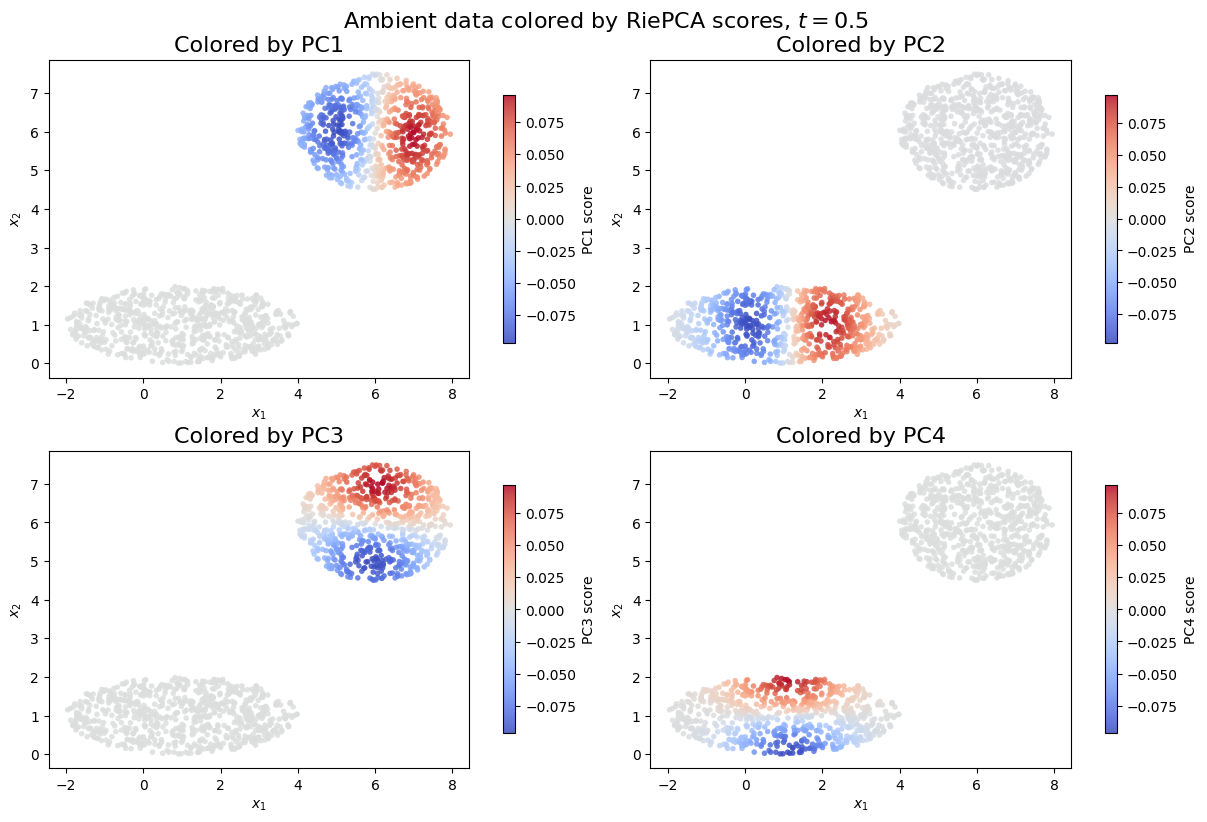

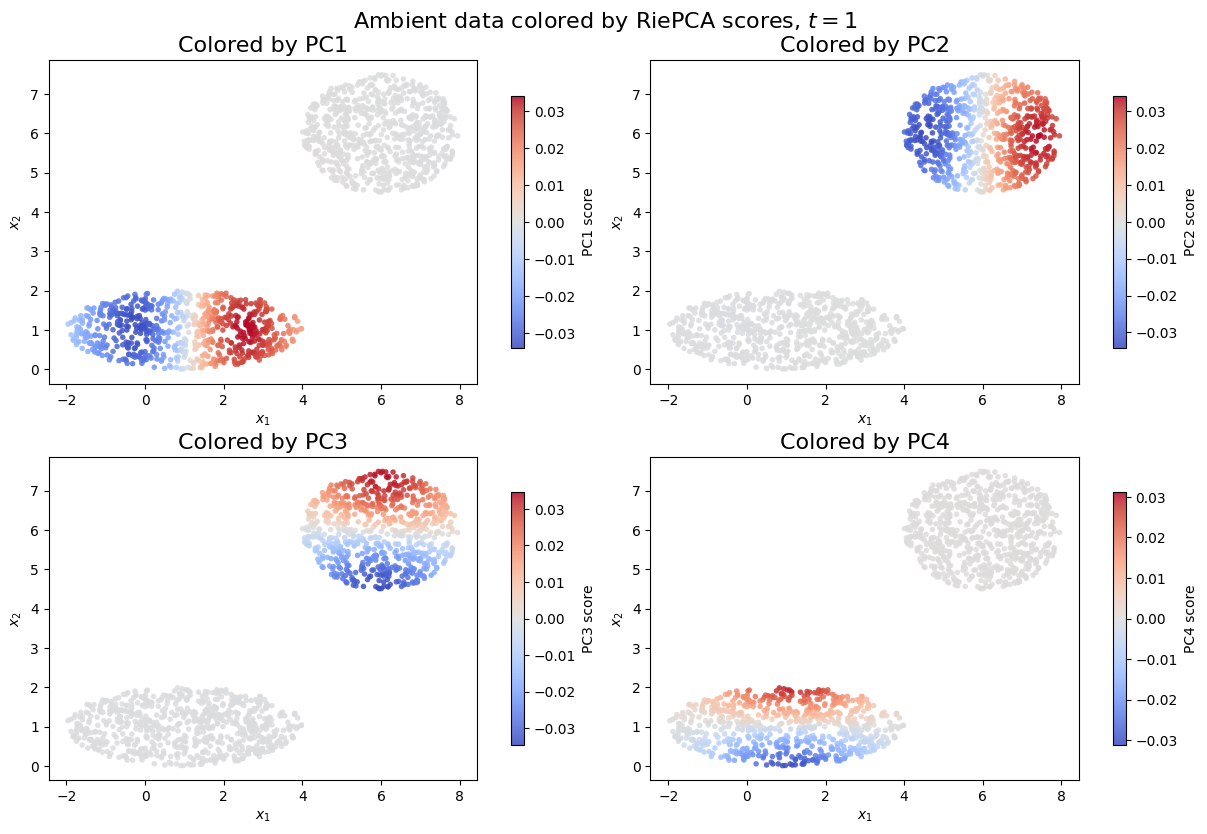

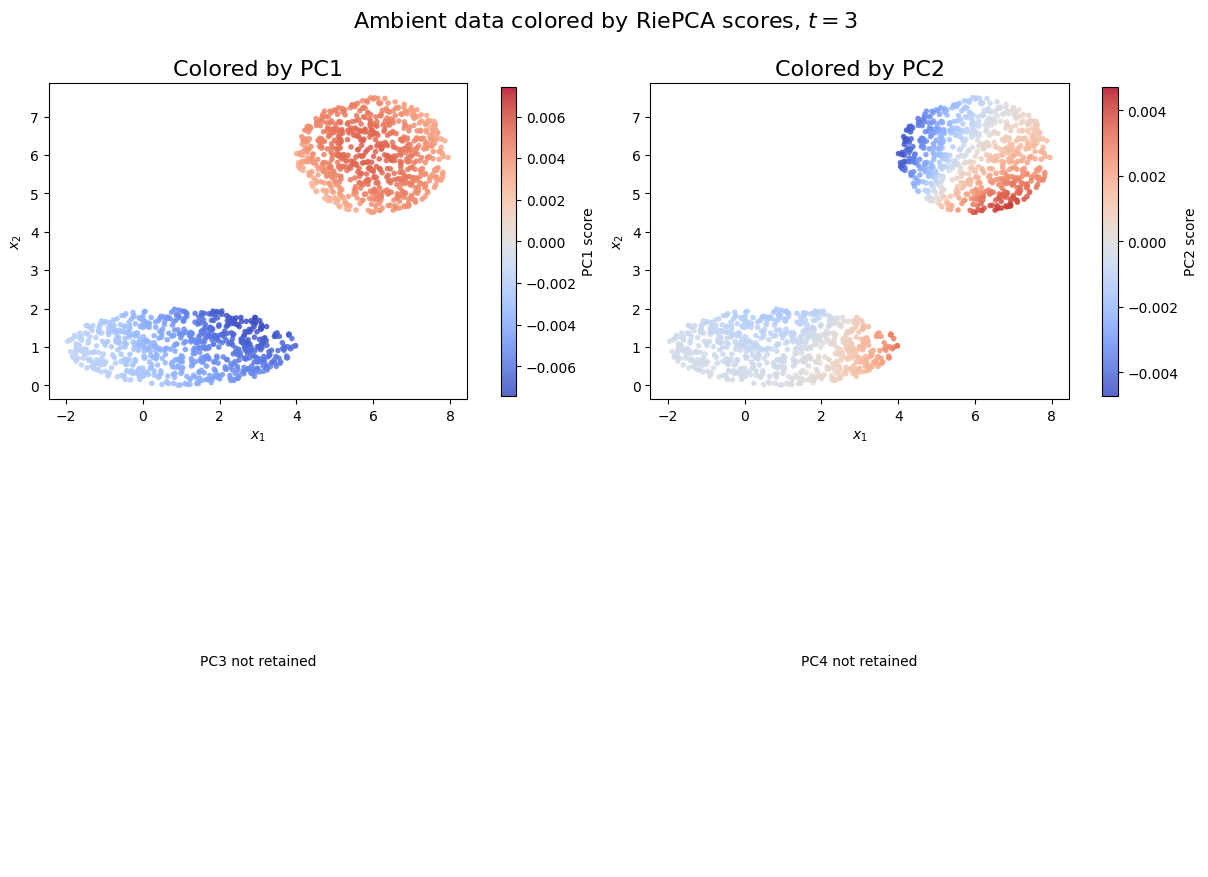

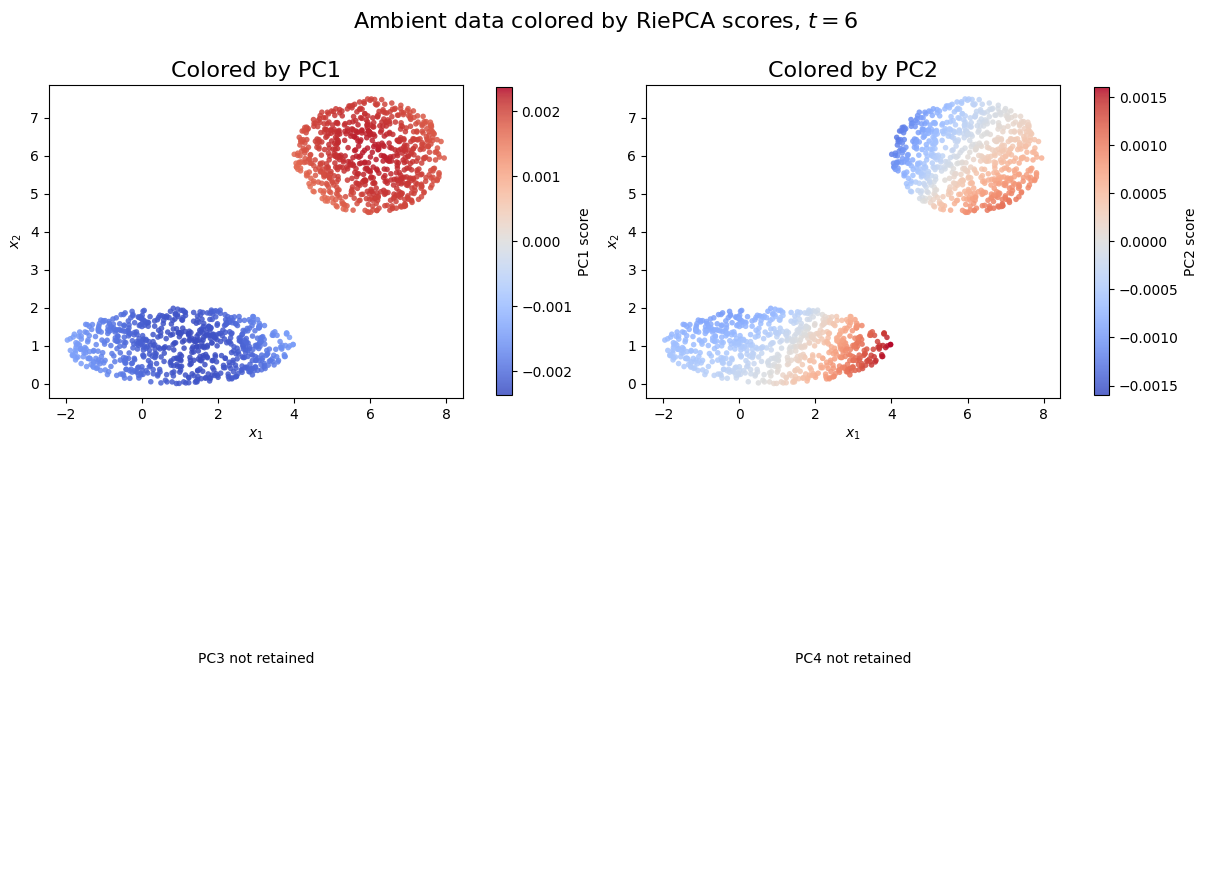

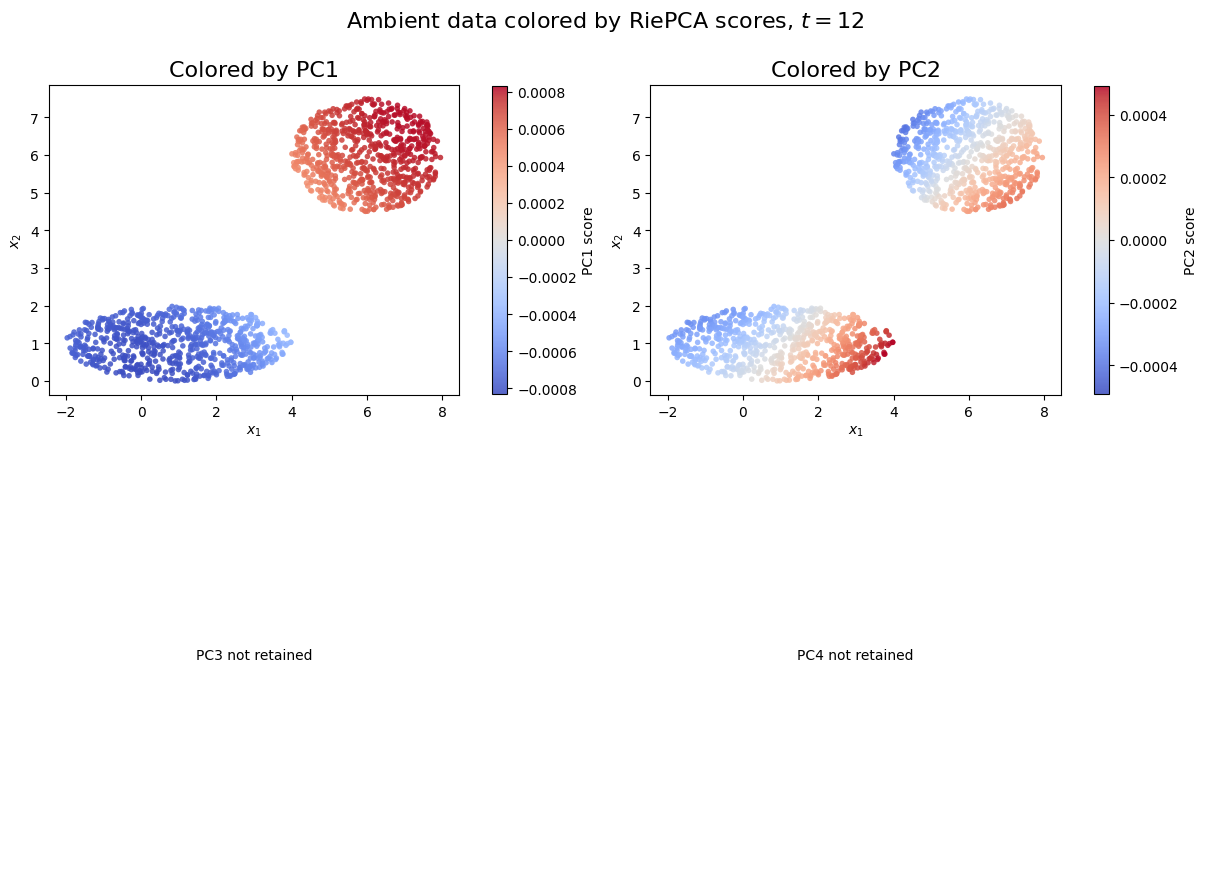

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

data_points_amb = riepca_results["data_points"]
t_values = riepca_results["t_values"]
projections_dict = riepca_results["projections_dict"]

ambient_dimension = data_points_amb.shape[1]
if ambient_dimension not in (2, 3):
    raise ValueError("Ambient visualization is supported only for R^2 or R^3.")

for t in t_values:
    scores = projections_dict[t]
    #fig = plt.figure(figsize=(12, 10), constrained_layout=True)
    fig = plt.figure(figsize=(12, 10), layout="compressed")
    fig.get_layout_engine().set(
        h_pad=0.01,
        hspace=0.01,
    )

    for pc_index in range(4):
        if ambient_dimension == 3:
            ax = fig.add_subplot(2, 2, pc_index + 1, projection="3d")
        else:
            ax = fig.add_subplot(2, 2, pc_index + 1)

        if pc_index >= scores.shape[1]:
            message = f"PC{pc_index + 1} not retained"
            (ax.text2D if ambient_dimension == 3 else ax.text)(
                0.5,
                0.5,
                message,
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_axis_off()
            continue

        pc_scores = scores[:, pc_index]
        vmax = float(np.max(np.abs(pc_scores))) or 1.0
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

        if ambient_dimension == 2:
            scatter = ax.scatter(
                data_points_amb[:, 0],
                data_points_amb[:, 1],
                c=pc_scores,
                cmap="coolwarm",
                norm=norm,
                s=16,
                alpha=0.85,
                linewidths=0,
                rasterized=True,
            )
            ax.set_xlabel(r"$x_1$")
            ax.set_ylabel(r"$x_2$")
            ax.set_aspect("equal", adjustable="box")
        else:
            scatter = ax.scatter(
                data_points_amb[:, 0],
                data_points_amb[:, 1],
                data_points_amb[:, 2],
                c=pc_scores,
                cmap="coolwarm",
                norm=norm,
                s=12,
                alpha=0.85,
                linewidths=0,
                rasterized=True,
            )
            ax.set_xlabel(r"$x_1$")
            ax.set_ylabel(r"$x_2$")
            ax.set_zlabel(r"$x_3$")
            ax.view_init(elev=20, azim=35)
            box_range = np.ptp(data_points_amb, axis=0)
            box_range[box_range == 0] = 1.0
            ax.set_box_aspect(box_range)

        ax.set_title(f"Colored by PC{pc_index + 1}", fontsize=16,)
        fig.colorbar(
            scatter,
            ax=ax,
            shrink=0.75,
            pad=0.08,
            label=f"PC{pc_index + 1} score",
        )

    fig.suptitle(
        rf"Ambient data colored by RiePCA scores, $t={t:g}$",
        fontsize=16,
    )
    finalize(
        fig,
        f"ambient_scores_PC1_PC4_t_{time_tag(t)}",
        subdir="ambient",
    )


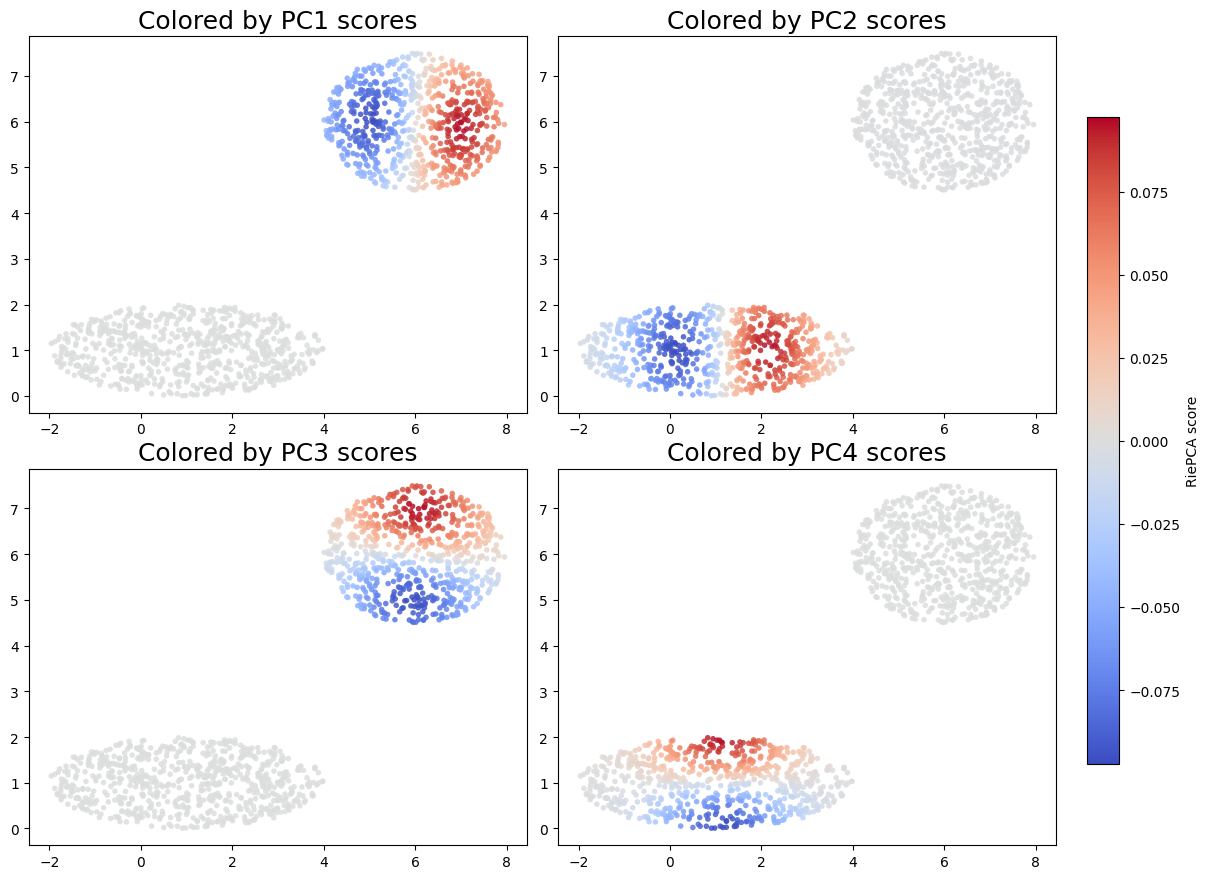

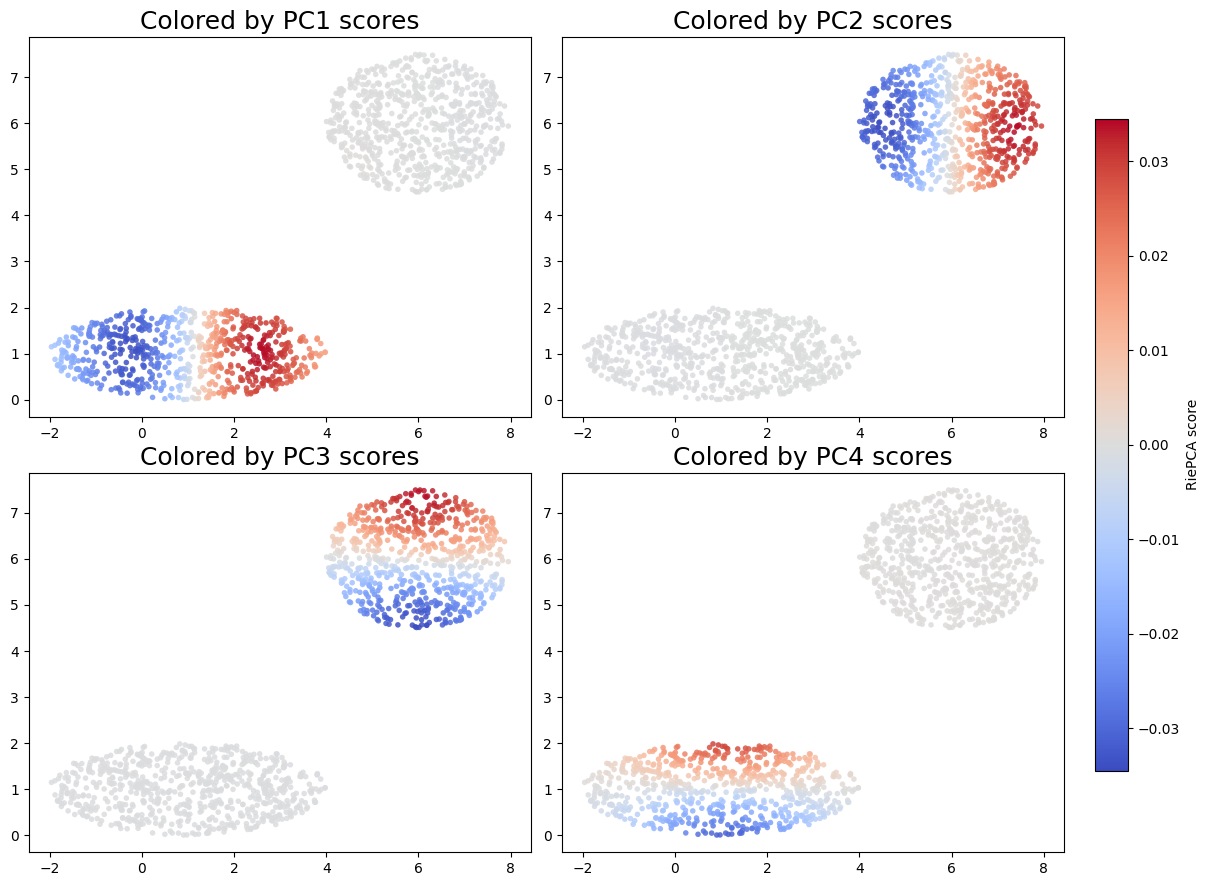

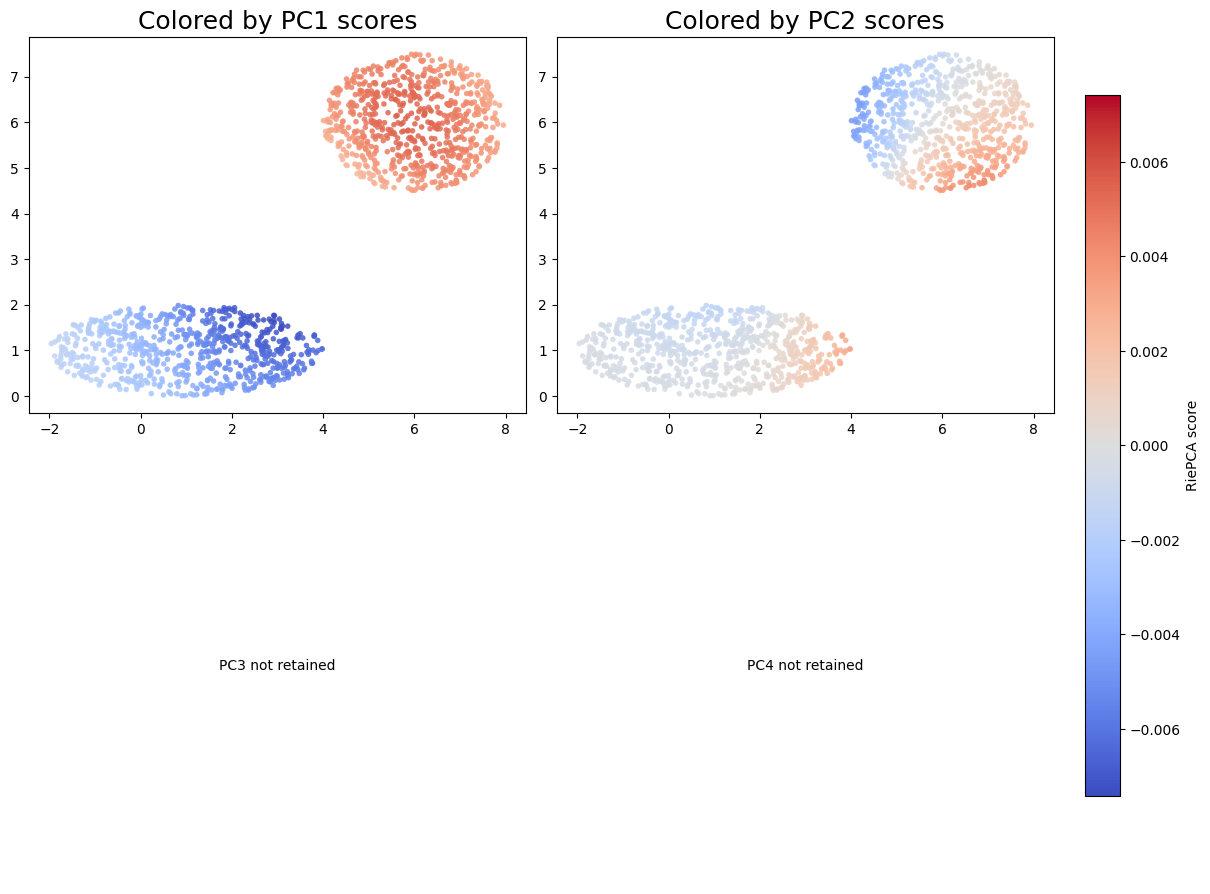

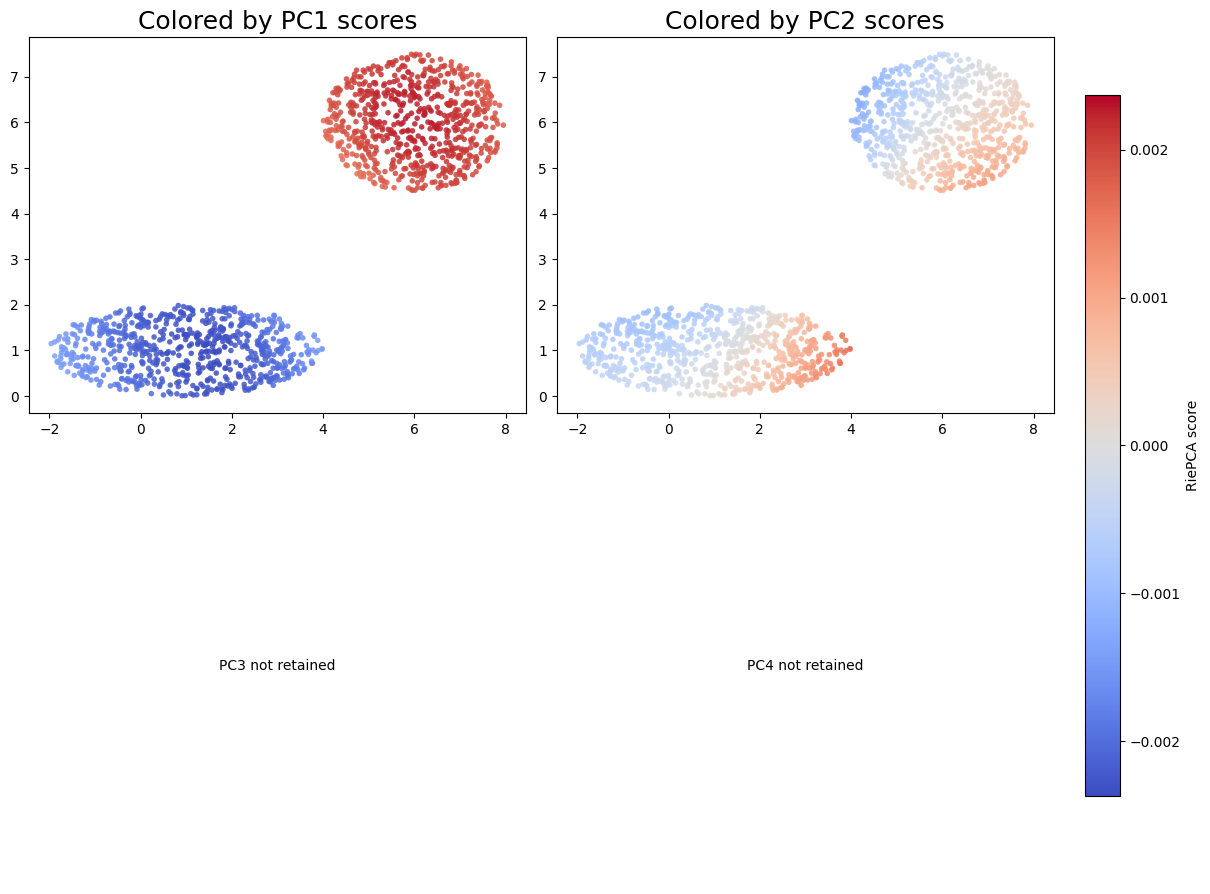

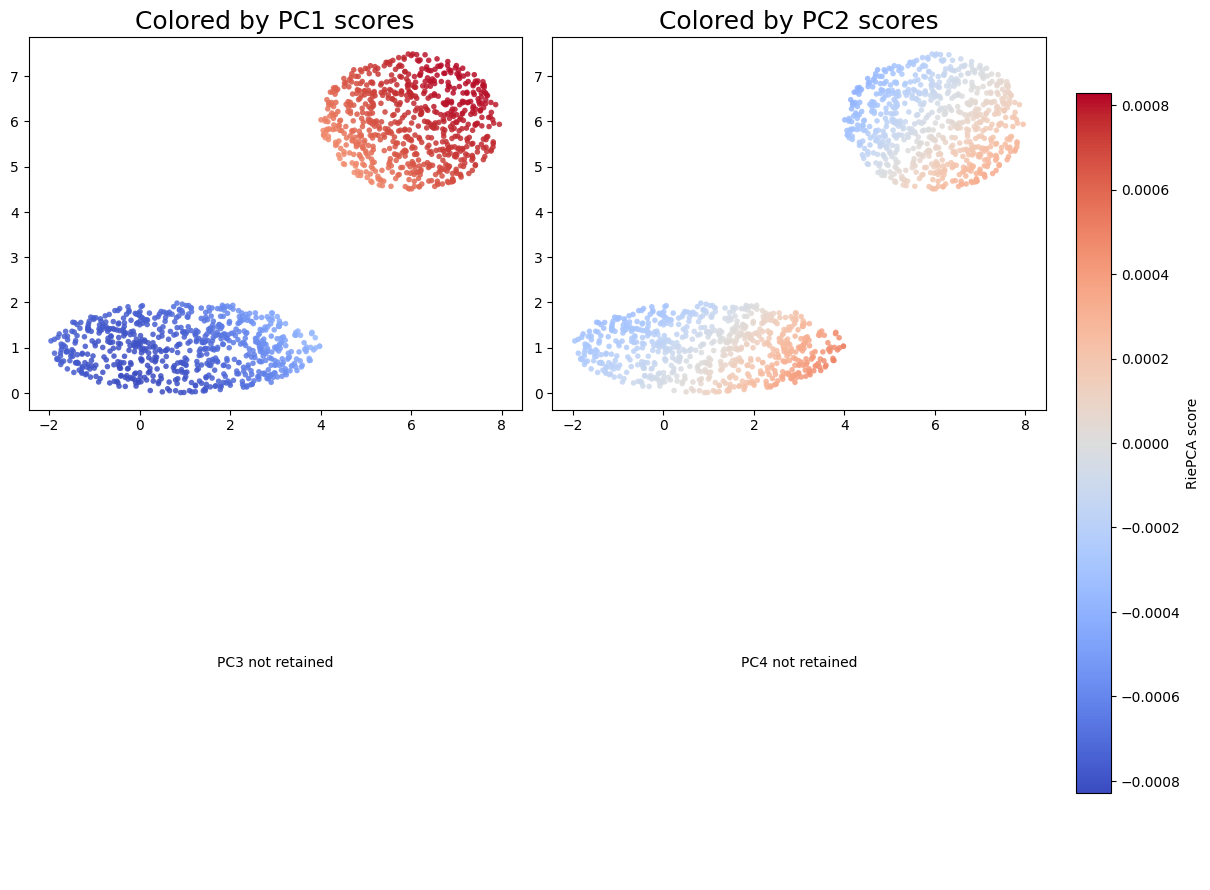

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

data_points_amb = riepca_results["data_points"]
t_values = riepca_results["t_values"]
projections_dict = riepca_results["projections_dict"]

ambient_dimension = data_points_amb.shape[1]

if ambient_dimension not in (2, 3):
    raise ValueError(
        "Ambient visualization is supported only for R^2 or R^3."
    )

for t in t_values:
    scores = projections_dict[t]

    fig = plt.figure(
        figsize=(12, 10),
        layout="compressed",
    )
    fig.get_layout_engine().set(
        h_pad=0.01,
        hspace=0.01,
    )

    # Use one common color scale across PC1–PC4.
    n_displayed = min(4, scores.shape[1])

    if n_displayed == 0:
        raise ValueError(f"No principal components were retained for t={t:g}.")

    displayed_scores = scores[:, :n_displayed]
    vmax = float(np.max(np.abs(displayed_scores))) or 1.0

    norm = TwoSlopeNorm(
        vmin=-vmax,
        vcenter=0.0,
        vmax=vmax,
    )

    subplot_axes = []

    for pc_index in range(4):
        if ambient_dimension == 3:
            ax = fig.add_subplot(
                2,
                2,
                pc_index + 1,
                projection="3d",
            )
        else:
            ax = fig.add_subplot(
                2,
                2,
                pc_index + 1,
            )

        subplot_axes.append(ax)

        if pc_index >= scores.shape[1]:
            message = f"PC{pc_index + 1} not retained"

            (ax.text2D if ambient_dimension == 3 else ax.text)(
                0.5,
                0.5,
                message,
                ha="center",
                va="center",
                transform=ax.transAxes,
            )

            ax.set_axis_off()
            continue

        pc_scores = scores[:, pc_index]

        if ambient_dimension == 2:
            ax.scatter(
                data_points_amb[:, 0],
                data_points_amb[:, 1],
                c=pc_scores,
                cmap="coolwarm",
                norm=norm,
                s=16,
                alpha=0.85,
                linewidths=0,
                rasterized=True,
            )

            #ax.set_xlabel(r"$x_1$")
            #ax.set_ylabel(r"$x_2$")
            ax.set_aspect("equal", adjustable="box")

        else:
            ax.scatter(
                data_points_amb[:, 0],
                data_points_amb[:, 1],
                data_points_amb[:, 2],
                c=pc_scores,
                cmap="coolwarm",
                norm=norm,
                s=12,
                alpha=0.85,
                linewidths=0,
                rasterized=True,
            )

            #ax.set_xlabel(r"$x_1$")
            #ax.set_ylabel(r"$x_2$")
            #ax.set_zlabel(r"$x_3$")
            ax.view_init(elev=20, azim=35)

            box_range = np.ptp(data_points_amb, axis=0)
            box_range[box_range == 0] = 1.0
            ax.set_box_aspect(box_range)

        ax.set_title(f"Colored by PC{pc_index + 1} scores",fontsize=18,)

    # One shared colorbar for all four PCs at the current t.
    colorbar_map = plt.cm.ScalarMappable(
        norm=norm,
        cmap="coolwarm",
    )
    colorbar_map.set_array([])

    fig.colorbar(
        colorbar_map,
        ax=subplot_axes,
        shrink=0.8,
        pad=0.03,
        label="RiePCA score",
    )

    #fig.suptitle(
        #rf"Ambient data colored by RiePCA scores, $t={t:g}$",
        #fontsize=16,
    #)

    finalize(
        fig,
        f"ambient_scores_PC1_PC4_t_{time_tag(t)}",
        subdir="ambient",
    )

In [33]:
# (PDF handling now lives inside finalize(); nothing to close here.)
print("Ambient-score figures saved under", FIGURE_DIR.resolve())


Ambient-score figures saved under /content/heat_kernel_RiePCA_plots
